In [1]:
import xarray as xr
import pandas as pd
import os
import numpy as np

In [2]:
ds_input = xr.open_zarr("/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1.zarr")
# ds_input = xr.open_zarr(
#     "/pscratch/sd/s/suryad/data/cm4_piControl_ocean_200yr_full_chunked.zarr"
# )

In [17]:
climatology = ds_input["hfds"].groupby("time.dayofyear").mean("time").compute()
# Remove the seasonal cycle (climatology) from the detrended data
day_of_year = ds_input["hfds"]["time"].dt.dayofyear
ds_input["hfds_anomalies"] = (
    ds_input["hfds"] - climatology.sel(dayofyear=day_of_year)
).compute()
levels = 19

In [3]:
# OM4 Test Period -  2014 - 8 years
years = 104
window = 8
dates = np.array(range(3, 365 * years, 5))
repeats = years // window
start_year = 2014
ds_input = ds_input.sel(time=slice("1975-01-01", None))
ds_groundtruth = ds_input.isel(time=slice(2903, 3503))  # 8 years

# OM4 Old (1990-2000)
# dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
#         68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
#        133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
#        198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
#        263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
#        328, 333, 338, 343, 348, 353, 358, 363])
# years = 100
# window = 10
# start_year = 1990
# dates = np.array(range(3, 365*years, 5))
# repeats = years // window
# ds_groundtruth = ds_input.isel(lev=slice(None, levels))
# ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31")) # 10 years

In [19]:
areacello = ds_groundtruth["areacello"]

<xarray.DataArray ()>
array(0.14797596)


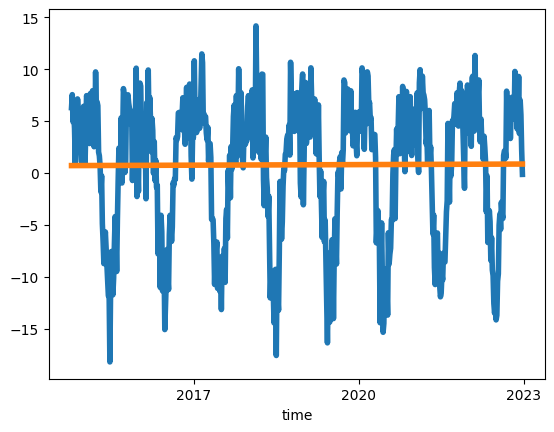

In [20]:
# View the trend in hfds
var = "hfds"  # hfds, hfds_anomalies

hfs_true = ds_groundtruth[var]
total_heat_flux = (hfs_true * areacello).sum(["x", "y"]) / areacello.sum(
    ["x", "y"]
)  # .sum(["lat", "lon"])

poly_coeffs = total_heat_flux.polyfit(dim="time", deg=1)
trend = xr.polyval(ds_groundtruth["time"], poly_coeffs.polyfit_coefficients)
print((trend[-1] - trend[0]).compute())

total_heat_flux.plot(lw=4)
trend.plot(lw=4)

<xarray.DataArray ()>
array(0.86991915)


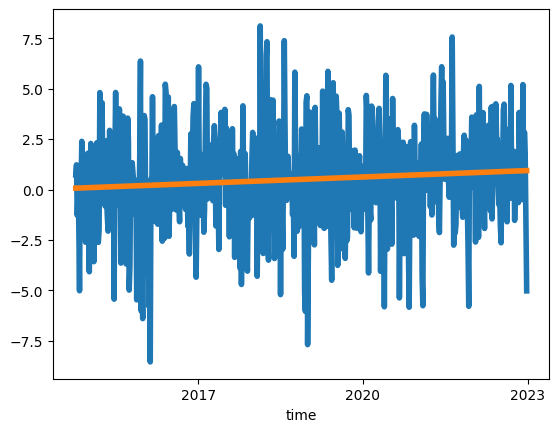

In [21]:
# View the trend in hfds
var = "hfds_anomalies"  # hfds, hfds_anomalies

hfs_true = ds_groundtruth[var]
total_heat_flux = (hfs_true * areacello).sum(["x", "y"]) / areacello.sum(
    ["x", "y"]
)  # .sum(["lat", "lon"])

poly_coeffs = total_heat_flux.polyfit(dim="time", deg=1)
trend = xr.polyval(ds_groundtruth["time"], poly_coeffs.polyfit_coefficients)
print((trend[-1] - trend[0]).compute())

total_heat_flux.plot(lw=4)
trend.plot(lw=4)

In [22]:
def detrend(ds, var="hfds"):
    # Detrend the data
    poly_coeffs = ds[var].polyfit(dim="time", deg=1)
    trend = xr.polyval(ds["time"], poly_coeffs.polyfit_coefficients).compute()

    # Remove the trend from the original data
    ds[var] = ds[var] - trend

    return ds

In [23]:
ds_groundtruth = detrend(ds_groundtruth, "hfds")
ds_groundtruth = detrend(ds_groundtruth, "hfds_anomalies")

<xarray.DataArray ()>
array(-9.89750722e-16)


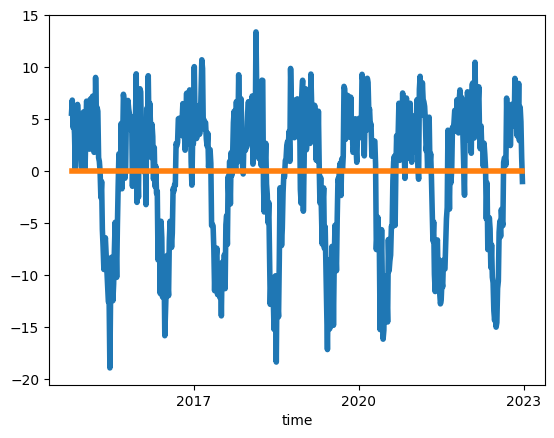

In [24]:
# View the trend in hfds
var = "hfds"  # hfds, hfds_anomalies

hfs_true = ds_groundtruth[var]
total_heat_flux = (hfs_true * areacello).sum(["x", "y"]) / areacello.sum(
    ["x", "y"]
)  # .sum(["lat", "lon"])

poly_coeffs = total_heat_flux.polyfit(dim="time", deg=1)
trend = xr.polyval(ds_groundtruth["time"], poly_coeffs.polyfit_coefficients)
print((trend[-1] - trend[0]).compute())

total_heat_flux.plot(lw=4)
trend.plot(lw=4)

<xarray.DataArray ()>
array(-1.80705051e-16)


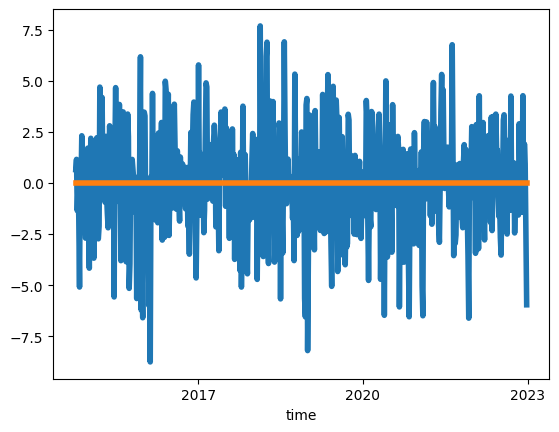

In [25]:
# View the trend in hfds
var = "hfds_anomalies"  # hfds, hfds_anomalies

hfs_true = ds_groundtruth[var]
total_heat_flux = (hfs_true * areacello).sum(["x", "y"]) / areacello.sum(
    ["x", "y"]
)  # .sum(["lat", "lon"])

poly_coeffs = total_heat_flux.polyfit(dim="time", deg=1)
trend = xr.polyval(ds_groundtruth["time"], poly_coeffs.polyfit_coefficients)
print((trend[-1] - trend[0]).compute())

total_heat_flux.plot(lw=4)
trend.plot(lw=4)

In [26]:
# Net Zero HF CC
new_time = np.array(
    [np.datetime64(str(start_year)) + np.timedelta64(day - 1, "D") for day in dates]
)
for i in range(1, repeats):
    new_time = np.hstack(
        (
            new_time,
            np.array(
                [
                    np.datetime64(str(start_year + i)) + np.timedelta64(day - 1, "D")
                    for day in dates
                ]
            ),
        )
    )
ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
ds_groundtruth["time"] = new_time[: len(ds_groundtruth.time)]
ds_groundtruth = ds_groundtruth.isel(time=slice(None, 7308))
ds_groundtruth.time

/tmp/ipykernel_1222115/3660686801.py:18: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth["time"] = new_time[: len(ds_groundtruth.time)]
/tmp/ipykernel_1222115/3660686801.py:18: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by convert

<xarray.DataArray 'time' (time: 7308)>
array(['2014-01-03T00:00:00.000000000', '2014-01-08T00:00:00.000000000',
       '2014-01-13T00:00:00.000000000', ..., '2114-01-04T00:00:00.000000000',
       '2114-01-09T00:00:00.000000000', '2114-01-14T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time       (time) datetime64[ns] 2014-01-03 2014-01-08 ... 2114-01-14
    dayofyear  (time) int64 283 288 293 298 303 308 313 ... 58 63 68 73 78 83 88

In [85]:
# CC 1 with Netzero hf (old format)
# new_time = np.array([np.datetime64(str(start_year)) + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(start_year+i)) + np.timedelta64(day-1,'D') for day in dates])))
# # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(np.arange(ds_groundtruth.time.size)*(1/73),(-1,1,1))
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(np.arange(ds_groundtruth.time.size)*(1/73),(-1,1,1))
# ds_groundtruth['time'] = new_time[:len(ds_groundtruth.time)]

In [27]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    ds_groundtruth.to_zarr(
        "/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1_with_hfds_anom_104_years_2014_netzerohfds_detrended",
        mode="w",
    )

[########################################] | 100% Completed | 68.89 s


In [28]:
total_heat_flux = (ds_groundtruth["hfds"] * ds_groundtruth["areacello"]).sum(["x", "y"])
heat_added = np.trapz(total_heat_flux.values, dx=5 * 3600 * 24)
print(heat_added)

2.0557172244624087e+22


### Convert to train ready code

In [29]:
ds = ds_groundtruth
ds

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 7308, y_b: 181, x_b: 361)
Coordinates: (12/13)
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ...              ...
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) datetime64[ns] 2014-01-03 2014-01-08 ... 2114-01-14
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    dayofyear       (time) int64 283 288 293 298 303 308 ... 63 68 73 78 83 88
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies  (time, y, x) float64 nan nan nan nan ... 1.677 1.69 1.702
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [30]:
assert [str(lev).replace(".", "_") for lev in ds["lev"].values] == [
    "2_5",
    "10_0",
    "22_5",
    "40_0",
    "65_0",
    "105_0",
    "165_0",
    "250_0",
    "375_0",
    "550_0",
    "775_0",
    "1050_0",
    "1400_0",
    "1850_0",
    "2400_0",
    "3100_0",
    "4000_0",
    "5000_0",
    "6000_0",
]

In [31]:
for lev in ds["lev"].values:
    lev_str = str(lev).replace(".", "_")

    # Create new variables for each original variable with the lev dimension
    ds[f"vo_lev_{lev_str}"] = ds["vo"].sel(lev=lev)
    ds[f"thetao_lev_{lev_str}"] = ds["thetao"].sel(lev=lev)
    ds[f"uo_lev_{lev_str}"] = ds["uo"].sel(lev=lev)
    ds[f"so_lev_{lev_str}"] = ds["so"].sel(lev=lev)

ds = ds.drop_vars(["vo", "thetao", "uo", "so"])
ds

<xarray.Dataset>
Dimensions:            (y: 180, x: 360, lev: 19, time: 7308, y_b: 181, x_b: 361)
Coordinates: (12/13)
    areacello          (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ...                 ...
    ocean_fraction     (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) datetime64[ns] 2014-01-03 ... 2114-01-14
    wetmask            (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y                  (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    dayofyear          (time) int64 283 288 293 298 303 308 ... 68 73 78 83 88
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    hfds               (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauuo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies     (time, y, x) float64 nan nan nan nan ... 1.677 1.69 1.702
    vo_lev_2_5         (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    uo_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_lev_6000_0  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    uo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [32]:
with ProgressBar():
    ds_mean = ds.mean().compute()

[########################################] | 100% Completed | 11m 30s


In [33]:
ds_mean.to_zarr(
    "/pscratch/sd/s/suryad/data/3D_data_OM4_5daily_v0.2.1_with_hfds_anom_104_years_2014_netzerohfds_detrended_means",
    mode="w",
)

In [34]:
with ProgressBar():
    ds_std = ds.std().compute()

[########################################] | 100% Completed | 14m 41s


In [35]:
ds_std.to_zarr(
    "/pscratch/sd/s/suryad/data/3D_data_OM4_5daily_v0.2.1_with_hfds_anom_104_years_2014_netzerohfds_detrended_stds",
    mode="w",
)

In [36]:
with ProgressBar():
    ds.to_zarr(
        "/pscratch/sd/s/suryad/data/3D_data_OM4_5daily_v0.2.1_with_hfds_anom_104_years_2014_netzerohfds_detrended",
        mode="w",
    )

[########################################] | 100% Completed | 10m 13s


In [30]:
ds.sel(time=slice("1990-01-03", "2089-12-04"))

<xarray.Dataset>
Dimensions:            (y: 180, x: 360, lev: 19, time: 7300, y_b: 181, x_b: 361)
Coordinates: (12/13)
    areacello          (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ...                 ...
    ocean_fraction     (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) datetime64[ns] 1990-01-03 ... 2089-12-04
    wetmask            (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y                  (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    dayofyear          (time) int64 3 8 13 18 23 28 ... 338 343 348 353 358 363
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    hfds               (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauuo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo              (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies     (time, y, x) float32 nan nan nan ... 0.9889 0.9856 0.9821
    vo_lev_2_5         (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    uo_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_5000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_lev_6000_0  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    uo_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_6000_0      (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative